In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import math
import boto3

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 29 10:37:35 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 29 10:37:35 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def target_by_data_set(df, str_target, str_dirname_output='./output'):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    
    # save
    str_filename = 'plt_target.png'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [3]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [5]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [6]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [7]:
# ks
def get_ks_score(y_true, y_pred):
    fpr, tpr, _ = skm.roc_curve(
        y_true=y_true,
        y_score=y_pred,
    )
    ks_stat = max(tpr - fpr)
    return ks_stat

In [8]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train, flt_auc_test

In [9]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    
    # save
    str_filename = 'performance.png'
    str_local_path = f'./output/{str_filename}'
    plt.savefig(str_local_path, bbox_inches='tight')
    
    # show
    plt.show()

In [10]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [11]:
def weight_the_coefficients(cls_model_inference, dict_weights):
    # features and coefficients
    list_feature_names_in = list(cls_model_inference.feature_names_in_)
    arr_coef = cls_model_inference.coef_[0]
    # multiply by weights and reassign
    for key, val in dict_weights.items():
        try:
            # get idx of feature
            int_idx = list_feature_names_in.index(key)
            # get the coef
            flt_coef = arr_coef[int_idx]
            # multiply by weight
            flt_coef = flt_coef * val
            # reassign
            arr_coef[int_idx] = flt_coef
        except ValueError:
            pass
    # reassign into model
    cls_model_inference.coef_[0] = arr_coef
    # return
    return cls_model_inference

In [12]:
def prep_for_partial_score(list_predictions, y_actual, flt_prop_pred=0.6):
    df_pred = pd.DataFrame({
        'pred': list_predictions,
        'actual': y_actual,
    })
    df_pred.sort_values(by='pred', ascending=True, inplace=True)
    # get rows
    int_nrows_subset = int(flt_prop_pred * len(df_pred))
    df_pred = df_pred.iloc[:int_nrows_subset].copy()
    # return
    return df_pred

In [13]:
# upload to s3
def upload_to_s3(str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

#### Constants

In [14]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target_tmp = str_task[3:].replace('_in_','_')
str_target = f'Early_Pay_Delinquency_{str_target_tmp}_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# number of columns in scorecard plot
int_ncols = 5

# weights
dict_weights = {
    'ENG-loan_to_value_binned': 1.0,
    'g106s__tu_binned': 1.0,
}

flt_prop_pred = 1.0

Project: 20241112-simple-model-test
Task: 09_60_in_720
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [15]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [16]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Hard code some bad features

In [17]:
list_cols_bad = [
    # flip
    'addrcurrenttimenewest__ln',
    'agg909__tu',
    'at27s__tu',
    'au51a__tu',
    'cv25__tu',
    'g200b__tu',
    'g219a__tu',
    'g410s__tu',
    'jt70s__tu',
    # doesnt make sense
    'linka024__tu',
    'linkt002__tu',
    'rvlr64__tu',
    # hurts train auc
]

#### Hard code features we want

In [18]:
list_cols_force = [
]

#### Get the features

In [19]:
str_filename = 'df_feat_imp.csv'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
df_feat_imp = pd.read_csv(str_local_path)
df_feat_imp['feature'] = df_feat_imp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# rm bad
df_feat_imp = df_feat_imp[~df_feat_imp['feature'].isin(list_cols_bad)].copy()
# get list of columns in the model
list_cols_model = list(df_feat_imp['feature'])
# add forced
list_cols_model = list_cols_model + list_cols_force
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
# get number of features
int_n_feats_final_scorecard = len(list_cols_model)
print(f'There are {int_n_feats_final_scorecard} features from which to select')
# rows for scorecard graph
int_nrows = math.ceil(int_n_feats_final_scorecard / int_ncols)
# show
df_feat_imp

There are 45 features from which to select


,feature,importance,importance_abs,description
0,fltgrossmonthly__income_sum,-0.011751,0.011751,NaN
1,au20s__tu,-0.011123,0.011123,Months since oldest auto trade opened
2,miles_odometer__app,0.010336,0.010336,NaN
3,rtl_trd__tu,-0.008863,0.008863,Number of retail trades
4,ENG-loan_to_value,0.008239,0.008239,NaN
5,g002s__tu,0.005798,0.005798,Number of 60 days past due ratings in past 12 ...
6,rev322__tu,-0.005718,0.005718,Min Total Open-to-Buy for Revolving accounts o...
7,balmag01__tu,-0.005717,0.005717,Non-mortgage balance magnitude algorithm over ...
11,g232s__tu,0.004913,0.004913,Number of inquiries (includes duplicates)
12,inquirybanking12month__ln,0.004857,0.004857,Indicates subject has one or more LexisNexis b...


#### Import data

In [20]:
list_cols_import = [
    'data_set',
    'request_datetime',
    'days_on_books',
    'applicationdate__app',
    'accountid',
    'bitdebtor__app',
    str_target,
    'ENG-loan_to_value',
    'ENG-bk',
    'ENG-franchise',
    'ENG-has_codebtor',
    'fltgrossmonthly__income_sum', # income
    'ENG-payment_to_income', # payment to income
    'ENG-dti',
    'ENG-wtd_avg',
]

# add features
list_cols_import = list_cols_import + list_cols_model
# rm dups
list_cols_import = list(dict.fromkeys(list_cols_import))
# import
list_str_filename = [
    'train',
    'test',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
        #columns=list_cols_import,
    )
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# make dt
df['request_date'] = df['request_datetime'].apply(
    lambda x: str(x)[:10],
)
df['request_date'] = pd.to_datetime(df['request_date']).dt.date
# save memory
del list_df
# show
df

100%|██████████| 3/3 [00:04<00:00,  1.61s/it]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout,request_date
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0.616667,2021-07-01,1,0.000024,train,1,0,0,2021-07-26
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,NaN,2021-07-01,2,0.000048,train,1,0,0,2021-07-26
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,NaN,2021-07-01,3,0.000072,train,1,0,0,2021-07-26
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,1,0.000000,2021-07-01,4,0.000096,train,1,0,0,2021-07-27
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,1,0.000000,2021-07-01,5,0.000120,train,1,0,0,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1,2022-11-30
41694,6418453,2022-11-30 23:48:36+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1,2022-11-30
41695,6411914,2022-11-30 23:53:12+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1,2022-11-30
41696,6434554,2022-11-30 23:57:04+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1,2022-11-30


#### Bad rate by BK by data set

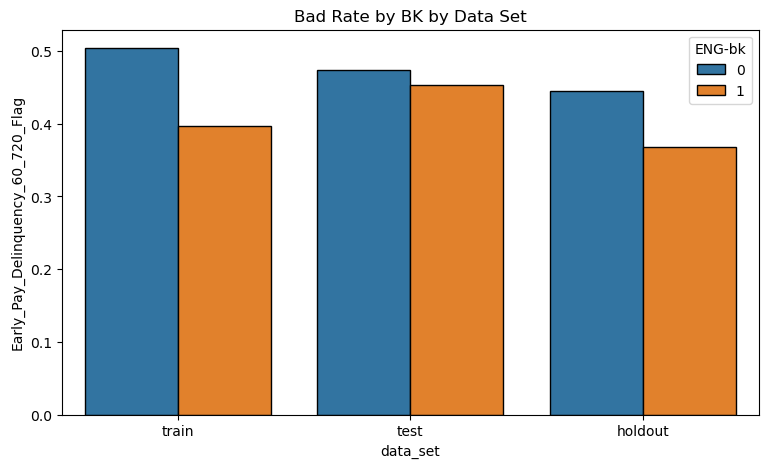

In [21]:
df_tmp = df.groupby(by=['data_set','ENG-bk'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-bk'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by BK by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-bk', ax=ax, dodge=True, edgecolor='black')

# save
str_filename = 'plt_bad_bk_dataset.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Bad rate by franchise by data set

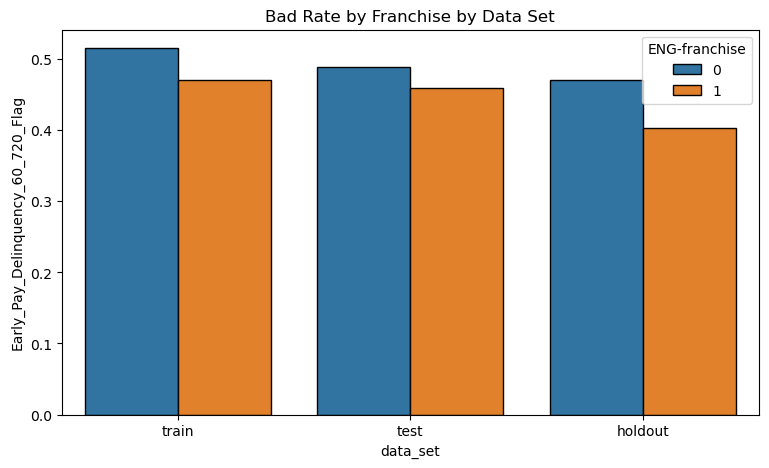

In [22]:
df_tmp = df.groupby(by=['data_set','ENG-franchise'], as_index=False).agg({
    str_target: 'mean',
})
# sort
df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
df_tmp.sort_values(by=['sort','ENG-franchise'], ascending=[True, True], inplace=True)
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Bad Rate by Franchise by Data Set')
sns.barplot(data=df_tmp, x='data_set', y=str_target, hue='ENG-franchise', ax=ax, dodge=True, edgecolor='black')

# save
str_filename = 'plt_bad_franchise_dataset.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Make table into a png image

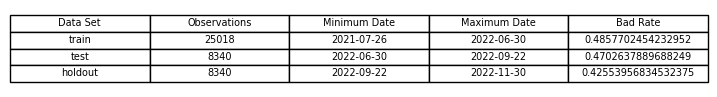

In [23]:
df['rows'] = 1
df['min_date'] = df['request_date']
df['max_date'] = df['request_date']
df_grouped = df.groupby(by='data_set', as_index=False).agg({
    'rows': 'count',
    'min_date': 'min',
    'max_date': 'max',
    str_target: 'mean',
})
# sort
df_grouped['sort'] = df_grouped['data_set'].map(dict_sort)
df_grouped.sort_values(by='sort', ascending=True, inplace=True)
df_grouped.drop('sort', axis=1, inplace=True)
# rename
dict_rename = {
    'data_set': 'Data Set',
    'rows': 'Observations',
    'min_date': 'Minimum Date',
    'max_date': 'Maximum Date',
    str_target: 'Bad Rate',
}
df_grouped.rename(columns=dict_rename, inplace=True)

# save
str_filename = 'df_info.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_grouped.to_csv(str_local_path, index=False)

# make into png
fig, ax = plt.subplots(figsize=(9,1))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=df_grouped.values, colLabels=df_grouped.columns, cellLoc='center', loc='center')

# save
str_filename = 'plt_info.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

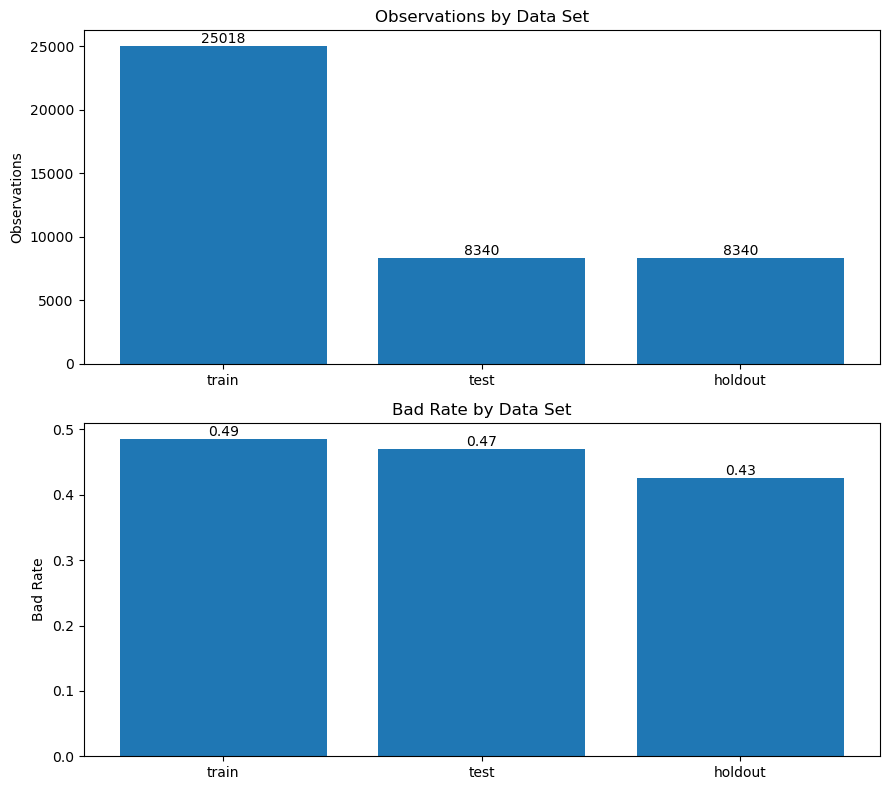

In [24]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(9,8))
# top plot
ax[0].set_title('Observations by Data Set')
ax[0].set_ylabel('Observations')
bars = ax[0].bar(df_grouped['Data Set'], df_grouped['Observations'])
ax[0].bar_label(bars)
# bottom plot
ax[1].set_title('Bad Rate by Data Set')
ax[1].set_ylabel('Bad Rate')
bars = ax[1].bar(df_grouped['Data Set'], df_grouped['Bad Rate'])
ax[1].bar_label(bars, fmt='%.2f')
# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_info_img.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Target mean by data set

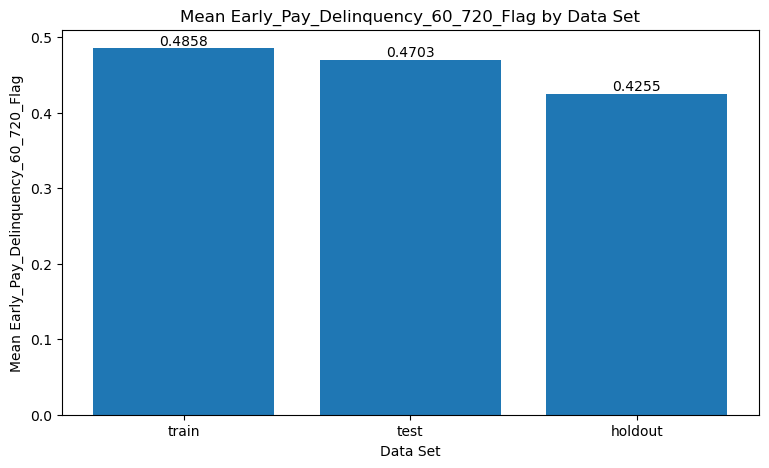

In [25]:
target_by_data_set(
    df=df,
    str_target=str_target,
    str_dirname_output=str_dirname_output,
)

#### Get relationship with target in training data

In [26]:
# import
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_monotone_constraints = pickle.load(open(str_local_path, 'rb'))

#### Create dictionary for imputation

In [27]:
# import
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

# impute
for key, val in tqdm(dict_impute.items()):
    try:
        # replace any infs with nan
        df[key] = df[key].replace(np.inf, np.nan)
        # fillna
        df[key] = df[key].fillna(val)
    except KeyError:
        pass
# show
df

100%|██████████| 1123/1123 [00:01<00:00, 830.26it/s]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,row,prop_row,data_set,train,test,holdout,request_date,rows,min_date,max_date
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,1,0.000024,train,1,0,0,2021-07-26,1,2021-07-26,2021-07-26
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,2,0.000048,train,1,0,0,2021-07-26,1,2021-07-26,2021-07-26
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,3,0.000072,train,1,0,0,2021-07-26,1,2021-07-26,2021-07-26
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,4,0.000096,train,1,0,0,2021-07-27,1,2021-07-27,2021-07-27
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,5,0.000120,train,1,0,0,2021-07-27,1,2021-07-27,2021-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,41694,0.999904,holdout,0,0,1,2022-11-30,1,2022-11-30,2022-11-30
41694,6418453,2022-11-30 23:48:36+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,41695,0.999928,holdout,0,0,1,2022-11-30,1,2022-11-30,2022-11-30
41695,6411914,2022-11-30 23:53:12+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,41696,0.999952,holdout,0,0,1,2022-11-30,1,2022-11-30,2022-11-30
41696,6434554,2022-11-30 23:57:04+00:00,GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,41697,0.999976,holdout,0,0,1,2022-11-30,1,2022-11-30,2022-11-30


#### Get bins

In [28]:
# import
str_filename = 'dict_bins.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_bins = pickle.load(open(str_local_path, 'rb'))

# transform
for key, val in tqdm(dict_bins.items()):
    try:
        df[f'{key}_binned'] = val.transform(df[key])
    except KeyError:
        pass

100%|██████████| 1119/1119 [00:02<00:00, 406.04it/s]


In [29]:
# get scorecard names
list_cols_scorecard = [f'{col}_binned' for col in list_cols_model]

# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = df[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
for a, col in enumerate(list_col_no_var):
    print(f'{a+1} - {col}')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 45/45 [00:00<00:00, 1334.48it/s]

There are 0 features with no variance after binning
There are 45 features available for scorecard inclusion


In [30]:
# show bins
str_filename = 'df_bins.csv'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
df_bins = pd.read_csv(str_local_path)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.109167,0.00,3469.44,10494,0.419458,0.513055,1
1,fltgrossmonthly__income_sum_binned,-0.096817,3470.00,3682.73,1304,0.052122,0.509969,2
2,fltgrossmonthly__income_sum_binned,-0.027970,3683.15,4098.75,2486,0.099368,0.492759,3
3,fltgrossmonthly__income_sum_binned,0.040308,4099.00,4339.03,1482,0.059237,0.475709,4
4,fltgrossmonthly__income_sum_binned,0.058628,4339.05,5249.89,3933,0.157207,0.471142,5
...,...,...,...,...,...,...,...,...
2364,phoneinputproblems__ln_binned,-0.039639,4.00,6.00,11217,0.448357,0.495676,2
2365,phoneinputsubjectcount__ln_binned,0.028913,0.00,4.00,14220,0.568391,0.478551,1
2366,phoneinputsubjectcount__ln_binned,-0.038041,5.00,5.00,10798,0.431609,0.495277,2
2367,alertregulatorycondition__ln_binned,-0.107256,0.00,1.00,16696,0.667360,0.512578,1


#### Get info from inform set

In [31]:
# # get the inform data set
# df_inform = df[df['data_set'] == 'holdout'].copy()
# # get target value
# flt_target_value = df_inform[str_target].mean()
# print(f'Target Value: {flt_target_value:0.4f}')

#### Get train to match the inform set

In [32]:
# %%time

# get the training data
df_train = df[df['data_set'] == 'train'].copy()

# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_train,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_train = cls_sample.sample()
# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_train

#### Get test to match the inform set


In [33]:
# %%time

# test
df_test = df[df['data_set'] == 'test'].copy()

# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_test,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_test = cls_sample.sample()
# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_test

#### List of columns to start

In [34]:
print(f'Starting with {len(list_cols_scorecard)} features:')
for a, col in enumerate(list_cols_scorecard):
    print(f'{a+1}: {col}')

Starting with 45 features:
1: fltgrossmonthly__income_sum_binned
2: au20s__tu_binned
3: miles_odometer__app_binned
4: rtl_trd__tu_binned
5: ENG-loan_to_value_binned
6: g002s__tu_binned
7: rev322__tu_binned
8: balmag01__tu_binned
9: g232s__tu_binned
10: inquirybanking12month__ln_binned
11: linkt003__tu_binned
12: all235__tu_binned
13: ENG-wtd_avg_binned
14: cv15__tu_binned
15: derogseverityindex__ln_binned
16: g407s__tu_binned
17: cv13__tu_binned
18: phoneinputproblems__ln_binned
19: ENG-franchise_binned
20: at24s__tu_binned
21: jt20s__tu_binned
22: subjectabilityindex__ln_binned
23: sourcenonderogcount12month__ln_binned
24: in21s__tu_binned
25: ENG-bk_binned
26: rp01s__tu_binned
27: trv01__tu_binned
28: bc97a__tu_binned
29: s068b__tu_binned
30: in34s__tu_binned
31: linka053__tu_binned
32: addrprevioustimenewest__ln_binned
33: addronfilecount__ln_binned
34: fi25s__tu_binned
35: fi101s__tu_binned
36: linka025__tu_binned
37: fi36s__tu_binned
38: linkf098__tu_binned
39: linka006__tu_binned

#### Split into X and y

In [35]:
# train
X_train = df_train[[col for col in list_cols_scorecard if col != str_target]].copy()
y_train = df_train[str_target]
# save memory
del df_train

In [36]:
# test
X_test = df_test[[col for col in list_cols_scorecard if col != str_target]].copy()
y_test = df_test[str_target]
# save memory
del df_test

In [37]:
# holdout
df_tmp = df[df['data_set'] == 'holdout'].copy()
X_holdout = df_tmp[[col for col in list_cols_scorecard if col != str_target]].copy()
y_holdout = df_tmp[str_target]
# assign
X_holdout['ENG-bk'] = df_tmp['ENG-bk']
X_holdout['ENG-franchise'] = df_tmp['ENG-franchise']
# save memory
del df, df_tmp

#### Scorecard

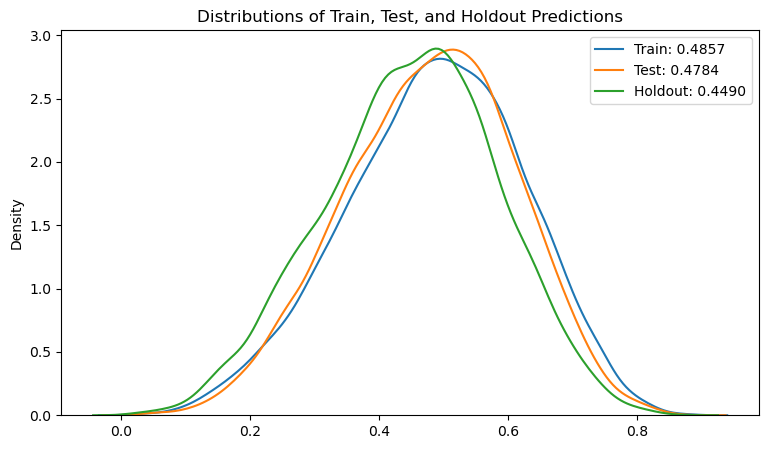

In [38]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [39]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6577
AUC Test: 0.6522
AUC Holdout: 0.6395

Logloss Train: 0.6525
Logloss Test: 0.6539
Logloss Holdout: 0.6525

KS Train: 0.2269
KS Test: 0.2163
KS Holdout: 0.2082


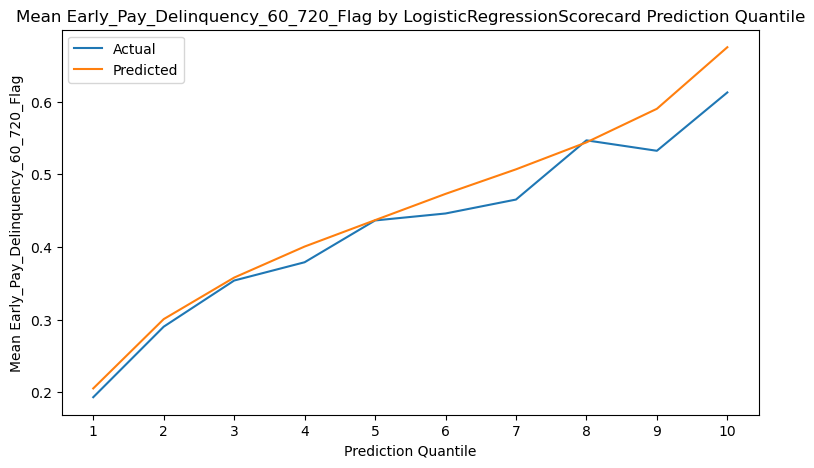

In [40]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

#### Sensitivity tuning/analysis

In [41]:
flt_auc_train_start = flt_auc_train
list_dict_row = []
for col_a in tqdm(list_cols_scorecard):
    # rm col
    list_cols_scorecard_tmp = [col_b for col_b in list_cols_scorecard if col_b != col_a]

    # init
    cls_model_inference = LogisticRegression(
        random_state=42,
        fit_intercept=True,
#             penalty='l1',
#             solver='liblinear',
    )
    # fit
    cls_model_inference.fit(
        X_train[list_cols_scorecard_tmp].copy(),
        y_train,
    )
    # adjust weights
    cls_model_inference = weight_the_coefficients(
        cls_model_inference=cls_model_inference,
        dict_weights=dict_weights,
    )

    # get predictions
    list_predictions_tmp = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_tmp])[:,1])
    # prep for partial score
    df_pred = prep_for_partial_score(
        list_predictions=list_predictions_tmp,
        y_actual=y_train,
        flt_prop_pred=flt_prop_pred,
    )
    # get auc
    flt_score = skm.roc_auc_score(
        y_true=df_pred['actual'],
        y_score=df_pred['pred'],
    )
    # make row
    dict_row = {
        'feature': col_a,
        'score': flt_score,
        'target': flt_auc_train_start,
    }
    # append
    list_dict_row.append(dict_row)
    
# make df
df_tmp = pd.DataFrame(list_dict_row)

# get diff
df_tmp['diff'] = df_tmp['score'] - df_tmp['target']

# make a copy
df_sensitivity = df_tmp.copy()
# sort
df_sensitivity.sort_values(by='diff', ascending=True, inplace=True)

# save
str_filename = 'df_sensitivity.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_sensitivity.to_csv(str_local_path, index=False)

# show
df_sensitivity

100%|██████████| 45/45 [00:06<00:00,  7.44it/s]


,feature,score,target,diff
14,derogseverityindex__ln_binned,0.654582,0.657739,-0.003157
7,balmag01__tu_binned,0.655437,0.657739,-0.002302
4,ENG-loan_to_value_binned,0.656045,0.657739,-0.001693
26,trv01__tu_binned,0.656325,0.657739,-0.001414
39,inquiryshortterm12month__ln_binned,0.656344,0.657739,-0.001395
23,in21s__tu_binned,0.656400,0.657739,-0.001339
0,fltgrossmonthly__income_sum_binned,0.656509,0.657739,-0.001230
2,miles_odometer__app_binned,0.656526,0.657739,-0.001213
3,rtl_trd__tu_binned,0.656569,0.657739,-0.001170
42,g095s__tu_binned,0.656726,0.657739,-0.001013


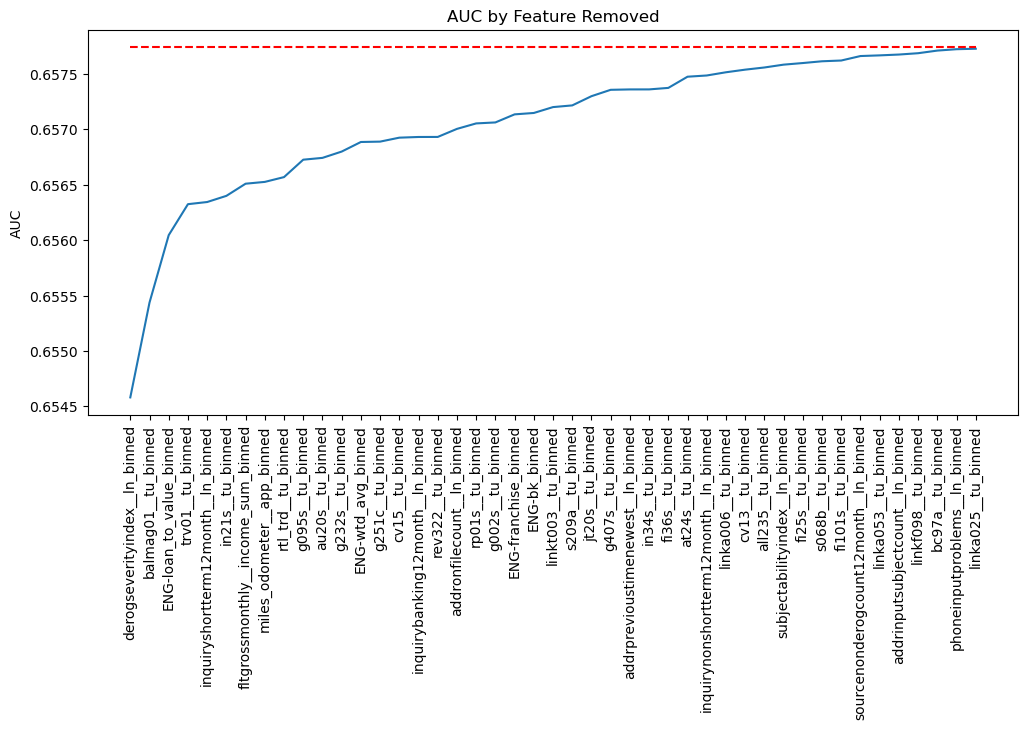

In [42]:
# plot
x = df_sensitivity['feature']
y = df_sensitivity['score']
z = df_sensitivity['target']
fig, ax = plt.subplots(figsize=(12,5))
ax.set_title('AUC by Feature Removed')
ax.set_ylabel('AUC')
ax.plot(x, y)
ax.plot(x, z, linestyle='--', color='red')
ax.set_xticklabels(x, rotation=90)
plt.show()

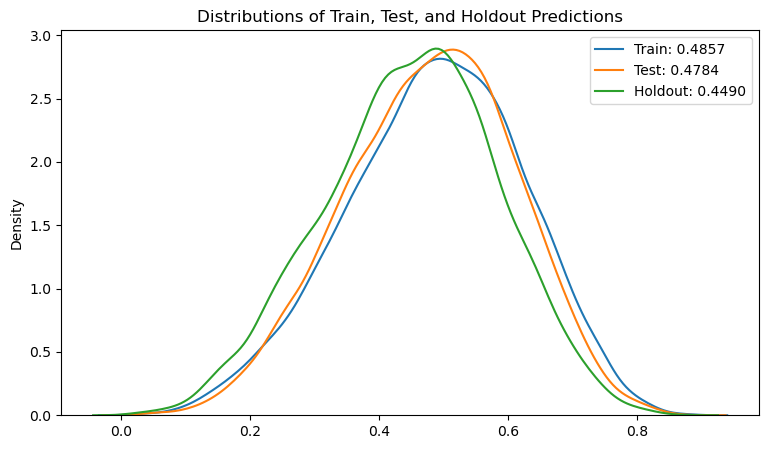

In [43]:
# rm
# list_cols_rm = list(df_tmp['feature'])
# list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_rm]

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
#     penalty='l1',
#     solver='liblinear',
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# save
str_filename = 'cls_model_inference_ml_logistic_scorecard.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(cls_model_inference, open(str_local_path, 'wb'))

# upload to s3
str_bucket_key = f'{str_task}/{str_subtask}/{str_filename}'
upload_to_s3(
    str_local_path=str_local_path,
    str_bucket_key=str_bucket_key,
    str_bucket_name=str_project,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

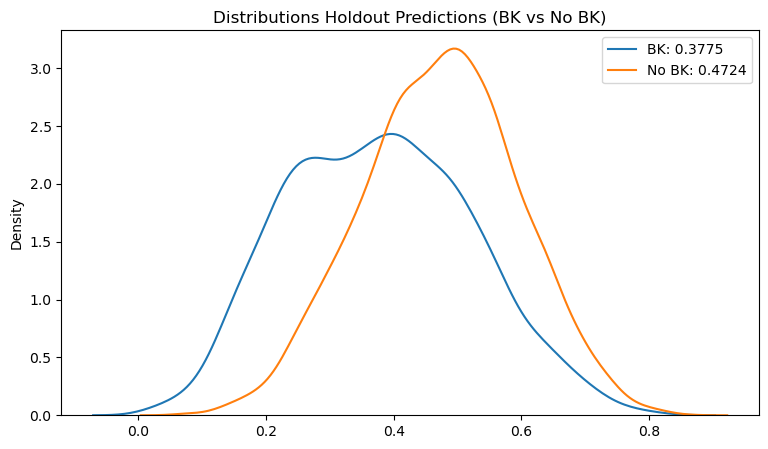

In [44]:
# holdout by bk non bk
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_bk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 1]['yhat'])
list_predictions_nobk = list(df_tmp_bk[df_tmp_bk['ENG-bk'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (BK vs No BK)')
sns.kdeplot(list_predictions_bk, label=f'BK: {np.mean(list_predictions_bk):0.4f}')
sns.kdeplot(list_predictions_nobk, label=f'No BK: {np.mean(list_predictions_nobk):0.4f}')
# legend
ax.legend()

# save
str_filename = 'plt_distributions_bk.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

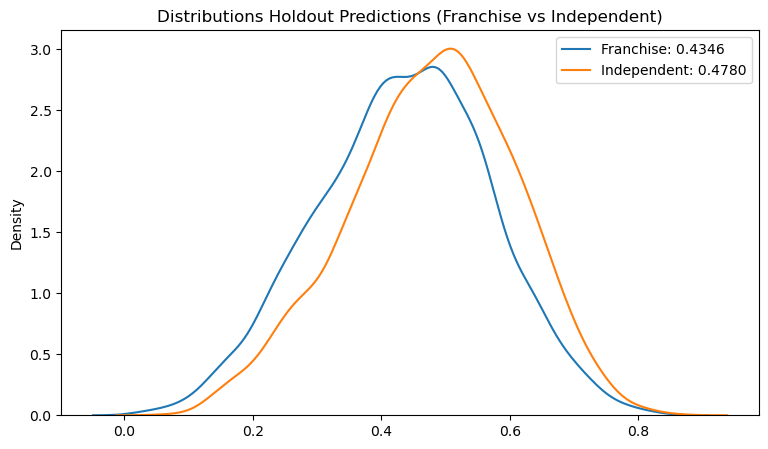

In [45]:
# holdout by franchise/ind
df_tmp_bk = X_holdout.copy()
df_tmp_bk['yhat'] = list_predictions_holdout
list_predictions_franchise = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 1]['yhat'])
list_predictions_independent = list(df_tmp_bk[df_tmp_bk['ENG-franchise'] == 0]['yhat'])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions Holdout Predictions (Franchise vs Independent)')
sns.kdeplot(list_predictions_franchise, label=f'Franchise: {np.mean(list_predictions_franchise):0.4f}')
sns.kdeplot(list_predictions_independent, label=f'Independent: {np.mean(list_predictions_independent):0.4f}')
# legend
ax.legend()

# save
str_filename = 'plt_distributions_dealer.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

In [46]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6577
AUC Test: 0.6522
AUC Holdout: 0.6395

Logloss Train: 0.6525
Logloss Test: 0.6539
Logloss Holdout: 0.6525

KS Train: 0.2269
KS Test: 0.2163
KS Holdout: 0.2082


#### Get intercept

In [47]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -0.060802493353093165


In [48]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
0,fltgrossmonthly__income_sum_binned,-0.011405,0.011405,NaN
2,miles_odometer__app_binned,0.009920,0.009920,NaN
1,au20s__tu_binned,-0.009259,0.009259,Months since oldest auto trade opened
3,rtl_trd__tu_binned,-0.008708,0.008708,Number of retail trades
4,ENG-loan_to_value_binned,0.008026,0.008026,NaN
6,rev322__tu_binned,-0.006039,0.006039,Min Total Open-to-Buy for Revolving accounts o...
7,balmag01__tu_binned,-0.005165,0.005165,Non-mortgage balance magnitude algorithm over ...
8,g232s__tu_binned,0.004912,0.004912,Number of inquiries (includes duplicates)
5,g002s__tu_binned,0.004893,0.004893,Number of 60 days past due ratings in past 12 ...
10,linkt003__tu_binned,-0.004751,0.004751,Number of non-military non-corroborated addres...


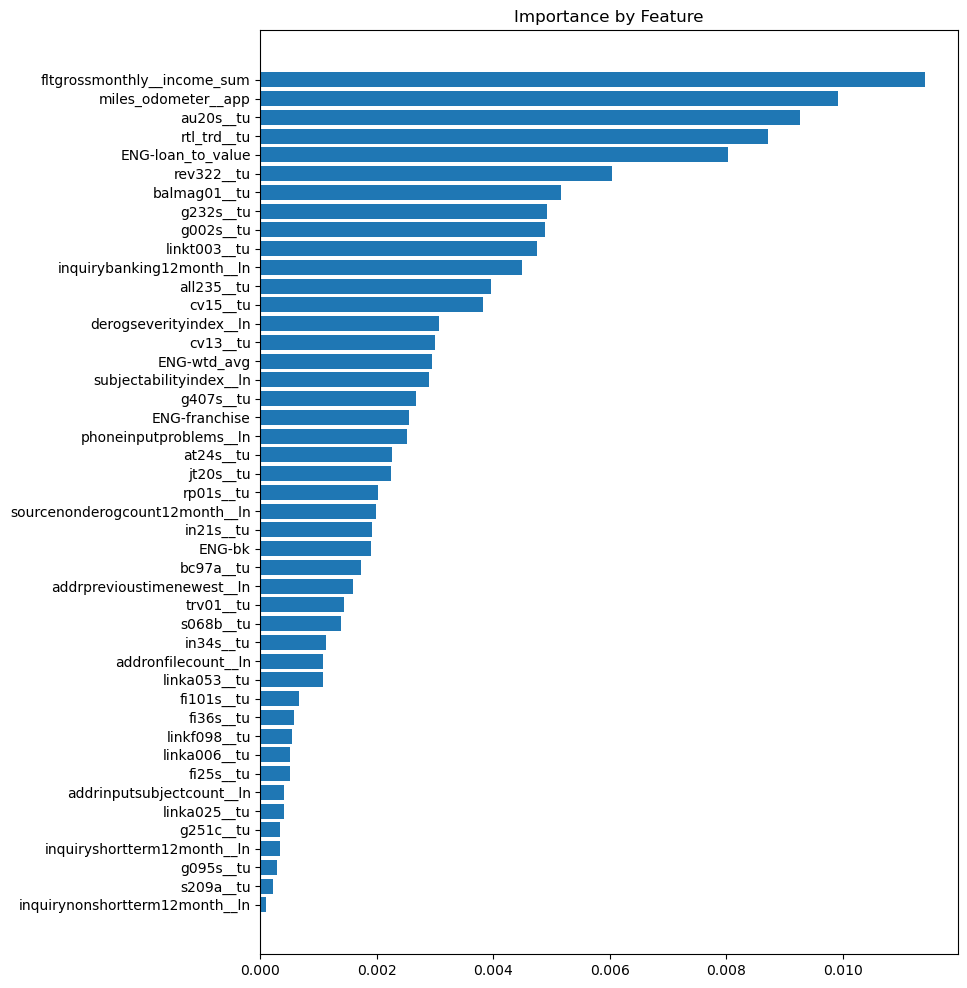

In [49]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Importance by Feature')
ax.barh(x, y)

# save
str_filename = 'feat_importance.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

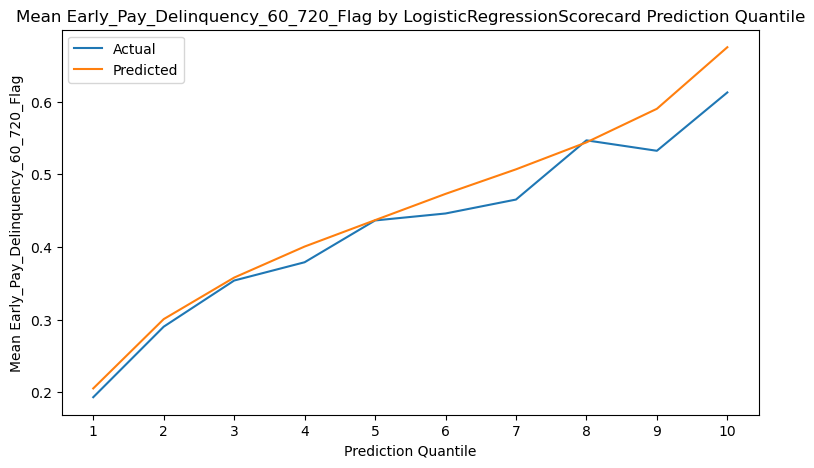

In [50]:
# mean actual by prediction quantile
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

In [51]:
# # directions of predictions
# int_n_quantiles = 10
# get_directions_of_predictions_for_scorecard(
#     X=X_holdout.copy(),
#     list_predictions=list_predictions_holdout,
#     str_target=str_target,
#     list_actual=list(y_holdout),
#     list_cols=list_cols_scorecard,
#     df_bins=df_bins,
# )

#### Show scorecard

In [52]:
# copy df_bins
df_identity = df_bins[df_bins['feature'].isin(list_cols_scorecard)].copy()

df_coef = pd.DataFrame({
    'feature': cls_model_inference.feature_names_in_,
    'coef': cls_model_inference.coef_[0],
})
# create dictionary
dict_map_coef = dict(zip(df_coef['feature'], df_coef['coef']))

# map to df_identity
df_identity['coef'] = df_identity['feature'].map(dict_map_coef)

# multiply by bin value
df_identity['contribution'] = df_identity['bin'] * df_identity['coef']

# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,True], inplace=True)

# get description
df_identity['description'] = df_identity['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_scorecard.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity.to_csv(str_local_path, index=False)

# show
df_identity

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
62,ENG-bk_binned,0.364446,1.000000,1.00000,4248,0.169798,0.396186,2,-0.440650,-0.160593,NaN
61,ENG-bk_binned,-0.073305,0.000000,0.00000,20770,0.830202,0.504092,1,-0.440650,0.032302,NaN
49,ENG-franchise_binned,0.062888,1.000000,1.00000,16327,0.652610,0.470080,2,-0.603274,-0.037939,NaN
48,ENG-franchise_binned,-0.117936,0.000000,0.00000,8691,0.347390,0.515246,1,-0.603274,0.071148,NaN
53,ENG-loan_to_value_binned,1.888976,0.185462,0.63156,32,0.001279,0.125000,1,-0.781223,-1.475711,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2135,subjectabilityindex__ln_binned,-0.030873,2.000000,2.00000,7905,0.315972,0.493485,2,-0.162242,0.005009,Modeled risk index indicating the subject's ab...
2134,subjectabilityindex__ln_binned,-0.092253,1.000000,1.00000,11723,0.468583,0.508829,1,-0.162242,0.014967,Modeled risk index indicating the subject's ab...
1785,trv01__tu_binned,0.331836,21.000000,999.00000,4834,0.193221,0.404013,3,-0.522354,-0.173336,Number of months since overlimit on a bankcard
1784,trv01__tu_binned,0.107232,4.000000,20.00000,1453,0.058078,0.459050,2,-0.522354,-0.056013,Number of months since overlimit on a bankcard


#### Graph it

100%|██████████| 45/45 [00:01<00:00, 29.17it/s]


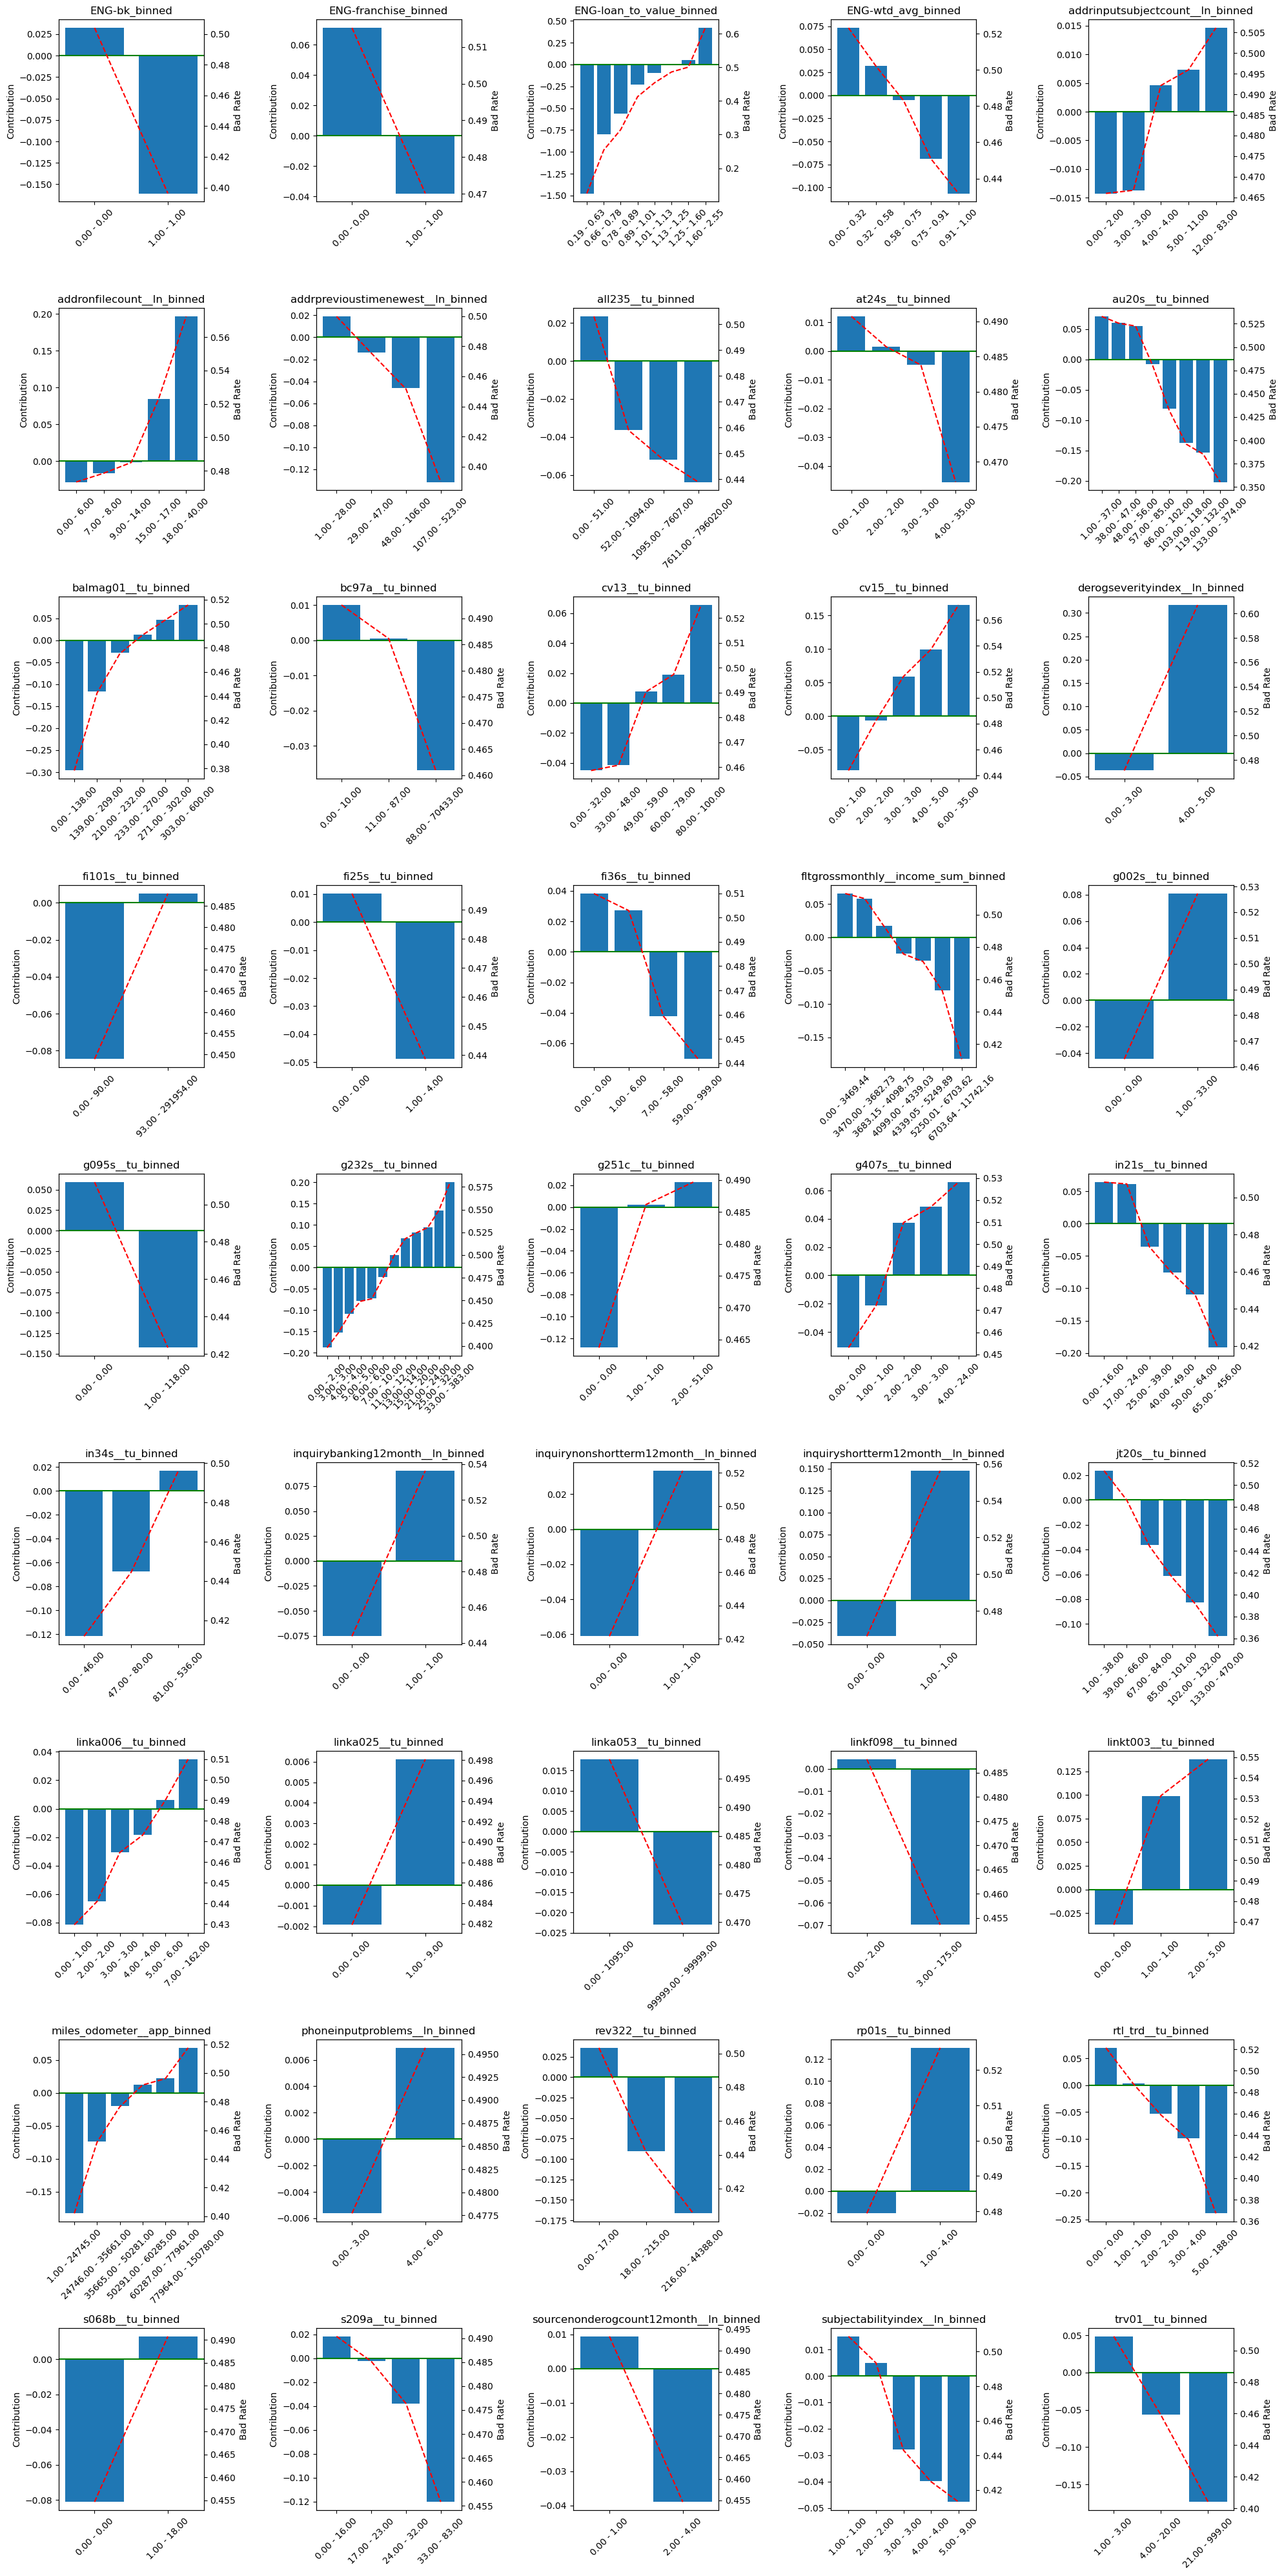

In [53]:
# get the unique values
list_feats_unique = list(df_identity['feature'].unique())

# plot
fig, ax = plt.subplots(nrows=int_nrows, ncols=int_ncols, figsize=(20, 40))

# iterate through features
counter = 0
int_row_start = 0
int_col_start = 0
for str_feat in tqdm(list_feats_unique):
    # logic for row, col
    if (int_col_start % int_ncols == 0) and (counter != 0):
        # add 1 to row
        int_row_start += 1
        # reset int_col_start
        int_col_start = 0
    else:
        pass
    
    # get row
    int_idx_row = int_row_start
    # get col
    int_idx_col = int_col_start
    # subset
    df_tmp = df_identity[df_identity['feature'] == str_feat].copy()
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create label
    df_tmp['label'] = df_tmp.apply(
        lambda x: f'{x["min"]:0.2f} - {x["max"]:0.2f}',
        axis=1,
    )
    # x and y
    x = df_tmp['label']
    y = df_tmp['contribution']
    z = df_tmp['target']
    # plot
    ax[int_idx_row, int_idx_col].set_title(str_feat)
    ax[int_idx_row, int_idx_col].set_ylabel('Contribution')
    ax[int_idx_row, int_idx_col].bar(x, y)
    ax[int_idx_row, int_idx_col].set_xticklabels(x, rotation=45)
    # horizontal line at 0
    ax[int_idx_row, int_idx_col].axhline(0, color='green')
    # second y
    ax2 = ax[int_idx_row, int_idx_col].twinx()
    ax2.set_ylabel('Bad Rate')
    ax2.plot(x, z, color='red', linestyle='--')
    # add
    counter += 1
    int_col_start += 1

# fix overlap
plt.tight_layout()

# save
str_filename = 'plt_scorecard.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show identity

In [54]:
df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
53,ENG-loan_to_value_binned,1.888976,0.185462,0.63156,32,0.001279,0.125000,1,-0.781223,-1.475711,NaN
1822,balmag01__tu_binned,0.439875,0.000000,138.00000,2469,0.098689,0.378291,1,-0.673531,-0.296269,Non-mortgage balance magnitude algorithm over ...
1749,rtl_trd__tu_binned,0.486387,5.000000,188.00000,2093,0.083660,0.367415,5,-0.490740,-0.238690,Number of retail trades
202,au20s__tu_binned,0.538127,133.000000,374.00000,1370,0.054761,0.355474,8,-0.375013,-0.201805,Months since oldest auto trade opened
766,in21s__tu_binned,0.269750,65.000000,456.00000,2835,0.113318,0.419048,6,-0.710869,-0.191757,Months since most recent installment trade opened
646,g232s__tu_binned,0.356970,0.000000,2.00000,1779,0.071109,0.397976,1,-0.526240,-0.187852,Number of inquiries (includes duplicates)
6,fltgrossmonthly__income_sum_binned,0.303691,6703.640000,11742.16000,2091,0.083580,0.410808,7,-0.601391,-0.182637,NaN
7,miles_odometer__app_binned,0.340548,1.000000,24745.00000,2712,0.108402,0.401917,1,-0.536178,-0.182594,NaN
1785,trv01__tu_binned,0.331836,21.000000,999.00000,4834,0.193221,0.404013,3,-0.522354,-0.173336,Number of months since overlimit on a bankcard
1364,rev322__tu_binned,0.326499,216.000000,44388.00000,2793,0.111640,0.405299,3,-0.509701,-0.166417,Min Total Open-to-Buy for Revolving accounts o...


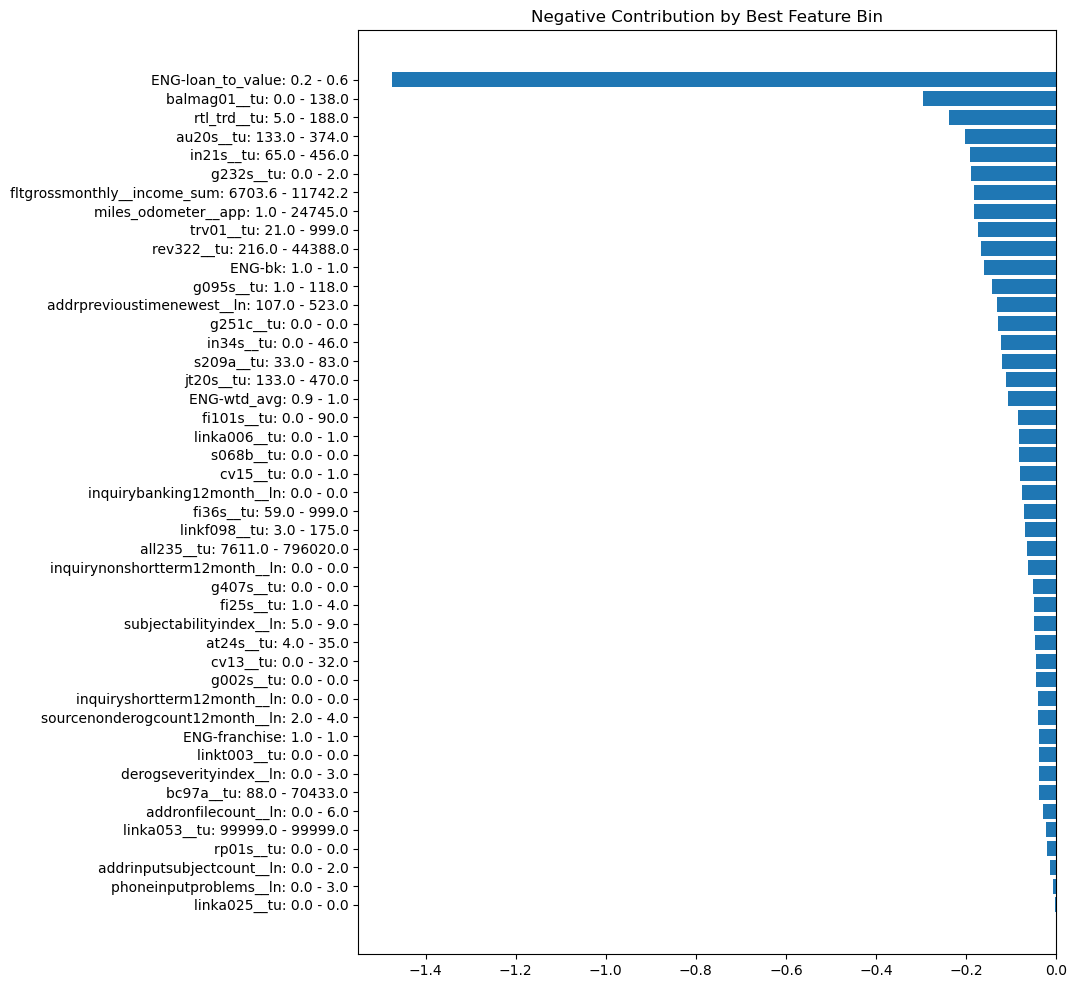

In [55]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=False, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Negative Contribution by Best Feature Bin')
ax.barh(x, y)

# save
str_filename = 'best_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Show what is not our identity

In [56]:
# sort
df_identity.sort_values(by=['feature','contribution'], ascending=[True,False], inplace=True)

df_identity_sub = df_identity.drop_duplicates(subset=['feature'], keep='first', inplace=False)

# sort
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)

# save
str_filename = 'df_scorecard_sub_anti.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_identity_sub.to_csv(str_local_path, index=False)

# show
df_identity_sub

,feature,bin,min,max,count,prop,target,bin_label,coef,contribution,description
1920,linkf098__tu_binned,-0.007887,0.000000,2.000000,23574,0.942282,0.487741,1,-0.541061,0.004268,Number of satisfactory trades
484,fi101s__tu_binned,-0.008677,93.000000,291954.000000,23628,0.944440,0.487938,2,-0.571156,0.004956,Total balance of all finance installment trade...
2040,linka025__tu_binned,-0.049256,1.000000,9.000000,5991,0.239468,0.498080,2,-0.124253,0.006120,Number of other inquiries in the last 3 years....
2364,phoneinputproblems__ln_binned,-0.039639,4.000000,6.000000,11217,0.448357,0.495676,2,-0.174453,0.006915,Indicates problems associated with the input p...
2160,sourcenonderogcount12month__ln_binned,-0.030216,0.000000,1.000000,20137,0.804900,0.493321,1,-0.311356,0.009408,Total non-derogatory source types on file for ...
306,bc97a__tu_binned,-0.027120,0.000000,10.000000,18516,0.740107,0.492547,1,-0.370444,0.010046,Total open to buy of open credit cards verifie...
456,fi25s__tu_binned,-0.039438,0.000000,0.000000,20691,0.827045,0.495626,1,-0.257572,0.010158,Number of currently open and satisfactory fina...
128,at24s__tu_binned,-0.019784,0.000000,1.000000,15991,0.639180,0.490714,1,-0.609192,0.012052,Number of currently open and satisfactory trad...
958,s068b__tu_binned,-0.019852,1.000000,18.000000,21576,0.862419,0.490730,2,-0.649896,0.012902,Number of non-medical third party collections
2247,addrinputsubjectcount__ln_binned,-0.081502,12.000000,83.000000,8711,0.348189,0.506142,5,-0.179525,0.014632,Total number of unique subjects on file curren...


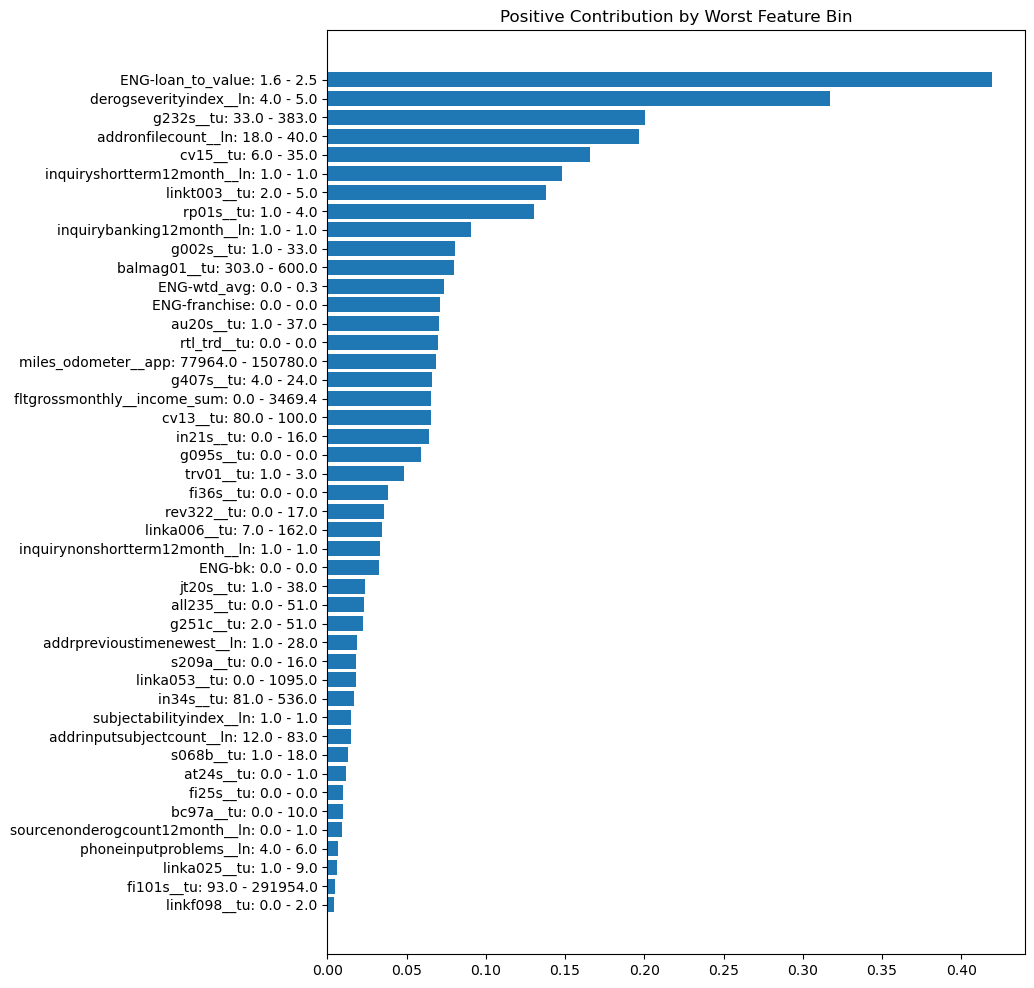

In [57]:
# plot
df_identity_sub['label'] = df_identity_sub.apply(
    lambda x: f"{x['feature'].split('_binned')[0]}: {x['min']:0.1f} - {x['max']:0.1f}",
    axis=1,
)

# plot
df_identity_sub.sort_values(by='contribution', ascending=True, inplace=True)
x = df_identity_sub['label']
y = df_identity_sub['contribution']
fig, ax = plt.subplots(figsize=(9,12))
ax.set_title('Positive Contribution by Worst Feature Bin')
ax.barh(x, y)

# save
str_filename = 'worst_bin.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()